# this is also the 3rd step 
* but in this instead of the no_relevent node we have webSearch 
* if the retrived document is not relevent then we re-write the query and do websearch and then again this node redirected to the node of is_relevent   

In [ ]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langchain_community.tools.tavily_search import TavilySearchResults


from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [6]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

    # web query (no loop flags)
    web_query: str

In [7]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [8]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [9]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [10]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}



In [11]:
# New
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}


In [12]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    docs = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        docs.append(
            Document(
                page_content=text,
                metadata={"source": "web", "url": url, "title": title},
            )
        )

    return {"docs": docs}


/var/folders/h1/gh59pbb174b94mbxsb8xb9qc0000gn/T/ipykernel_87698/948566410.py:25: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


* if the retrived document is not relevent then we re-write the query and do websearch and then again this node redirected to the node of is_relevent 

In [13]:
# New
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [14]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [15]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "rewrite_query"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "rewrite_query"


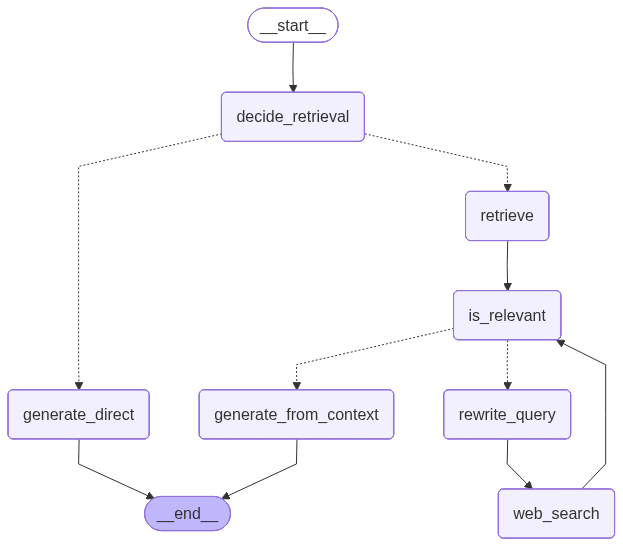

In [16]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)

# ✅ new nodes (replace no_relevant_docs)
g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)

# vector retrieval → relevance
g.add_edge("retrieve", "is_relevant")

# relevance router: if relevant → generate, else → rewrite_query
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "rewrite_query": "rewrite_query",
    },
)

# web fallback path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "is_relevant")  # 🔁 circle back

# final
g.add_edge("generate_from_context", END)

app = g.compile()
app


In [23]:
result = app.invoke(
    {
        "question": "Who won the Aus vs Zim World T20 match 2026 and who was the top scorer",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

Zimbabwe won the Aus vs Zim World T20 match in 2026 by 23 runs. The top scorer for Zimbabwe was Brian Bennett, who scored an unbeaten 64 runs. For Australia, the top scorer was Matt Renshaw with 65 runs.


In [22]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

TITLE: Australia vs Zimbabwe, ICC Men's T20 World Cup 2026, 19th Match ...
URL: https://www.espn.com/cricket/series/8604/game/1512737/australia-vs-zimbabwe-19th-match-group-b-8604
CONTENT:
2.55pm Right then, we officially have the first upset of the 2026 T20 World Cup, with Zimbabwe's statement win over Australia. It's been an incredible game of cricket, and it opens Group B up for a thrilling conclusion. Sri Lanka have to play both Australia and Zimbabwe, and right now, it is hard to tell who will progress from this group. Zimbabwe will celebrate a win for the ages before recalibrating for their next game. Australia will hope for reinforcements to arrive swiftly, with more injury worries after today's game. That's all from the Premadasa from us today. Next on the menu is Canada taking on UAE in Delhi, where Canada will be batting first. Head on over there for more T20 World Cup action. From this game, it's Abhimanyu signing off on behalf of Ranjith, and everyone else at [...] signing 

In [24]:
len(result['relevant_docs'])

5